# Deceptive Metrics And Data Leakage Study
This dataset features all building permits issued or in progress within the city of Seattle; it is taken from the website (data.gov). This project is an intentional dive into why real world machine learning pipelines fail. Instead of hiding an imperfect model, this notebook is just to show what I learned about data imbalance, leackage, and how a bad goal can result in a model that doesnt solve any real problem.

*   The first half is going to be just the code and everything I've done
*   The second half is going to be the explanation of what caused the model to behave the way it did.



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

# Path pattern: /content/drive/MyDrive/[Your_Folder_Name]/[Your_File_Name]
file_path = '/content/drive/MyDrive/Building_Permits.csv'

df = pd.read_csv(file_path)
df.head()


/tmp/ipykernel_429/3653671937.py:6: DtypeWarning: Columns (30,31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,PermitNum,PermitClass,PermitClassMapped,PermitTypeMapped,PermitTypeDesc,Description,HousingUnits,HousingUnitsRemoved,HousingUnitsAdded,EstProjectCost,...,InitialReviewCompleteDate,PlanReviewCompleteDate,DaysIssuePermitCity,ReadyToIssueDate,Zoning,DwellingUnitType,StandardPlan,DependentBuilding,ParentPermitNum,HousingCategory
0,3001095-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Street Improvement Exception,Exception/Exemption Request for: Land Use Appl...,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,3001906-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land Use Appl...,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,3002070-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land use perm...,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,3002774-EX,NaN,NaN,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: CANACELED 8-...,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,3003123-EX,Multifamily,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land Use appl...,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


In [3]:
pd.set_option('display.max_columns',None)
df.columns


Index(['PermitNum', 'PermitClass', 'PermitClassMapped', 'PermitTypeMapped',
       'PermitTypeDesc', 'Description', 'HousingUnits', 'HousingUnitsRemoved',
       'HousingUnitsAdded', 'EstProjectCost', 'AppliedDate', 'IssuedDate',
       'ExpiresDate', 'CompletedDate', 'StatusCurrent', 'RelatedMup',
       'OriginalAddress1', 'OriginalCity', 'OriginalState', 'OriginalZip',
       'ContractorCompanyName', 'Link', 'Latitude', 'Longitude', 'Location1',
       'TotalDaysPlanReview', 'DaysInitialPlanReview', 'DaysPlanReviewCity',
       'DaysOutCorrections', 'NumberReviewCycles', 'InitialReviewCompleteDate',
       'PlanReviewCompleteDate', 'DaysIssuePermitCity', 'ReadyToIssueDate',
       'Zoning', 'DwellingUnitType', 'StandardPlan', 'DependentBuilding',
       'ParentPermitNum', 'HousingCategory'],
      dtype='object')

In [4]:
df.dtypes

,0
PermitNum,object
PermitClass,object
PermitClassMapped,object
PermitTypeMapped,object
PermitTypeDesc,object
Description,object
HousingUnits,int64
HousingUnitsRemoved,float64
HousingUnitsAdded,float64
EstProjectCost,float64


In [5]:
df.isnull().mean()*100

,0
PermitNum,0.000000
PermitClass,3.614622
PermitClassMapped,3.614622
PermitTypeMapped,0.000000
PermitTypeDesc,6.702614
Description,0.394056
HousingUnits,0.000000
HousingUnitsRemoved,52.396298
HousingUnitsAdded,52.396298
EstProjectCost,18.439393


In [6]:
#Columns that are above 40% null  will be dropped
df=df.drop('HousingUnitsRemoved',axis=1)
df=df.drop('HousingUnitsAdded',axis=1)
df=df.drop('CompletedDate',axis=1)
df=df.drop('RelatedMup',axis=1)
df=df.drop('ContractorCompanyName',axis=1)
df=df.drop('TotalDaysPlanReview',axis=1)
df=df.drop('DaysInitialPlanReview',axis=1)
df=df.drop('DaysPlanReviewCity',axis=1)
df=df.drop('InitialReviewCompleteDate',axis=1)
df=df.drop('PlanReviewCompleteDate',axis=1)
df=df.drop('DaysIssuePermitCity',axis=1)
df=df.drop('ReadyToIssueDate',axis=1)
df=df.drop('Zoning',axis=1)
df=df.drop('DwellingUnitType',axis=1)
df=df.drop('StandardPlan',axis=1)
df=df.drop('ParentPermitNum',axis=1)
#df=df.drop('HousingCategory',axis=1)
df.columns


Index(['PermitNum', 'PermitClass', 'PermitClassMapped', 'PermitTypeMapped',
       'PermitTypeDesc', 'Description', 'HousingUnits', 'EstProjectCost',
       'AppliedDate', 'IssuedDate', 'ExpiresDate', 'StatusCurrent',
       'OriginalAddress1', 'OriginalCity', 'OriginalState', 'OriginalZip',
       'Link', 'Latitude', 'Longitude', 'Location1', 'DaysOutCorrections',
       'NumberReviewCycles', 'DependentBuilding', 'HousingCategory'],
      dtype='object')

In [7]:
df

,PermitNum,PermitClass,PermitClassMapped,PermitTypeMapped,PermitTypeDesc,Description,HousingUnits,EstProjectCost,AppliedDate,IssuedDate,ExpiresDate,StatusCurrent,OriginalAddress1,OriginalCity,OriginalState,OriginalZip,Link,Latitude,Longitude,Location1,DaysOutCorrections,NumberReviewCycles,DependentBuilding,HousingCategory
0,3001095-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Street Improvement Exception,Exception/Exemption Request for: Land Use Appl...,0,NaN,NaN,NaN,NaN,Completed,5414 21ST AVE SW,SEATTLE,WA,98106.0,https://services.seattle.gov/portal/customize/...,47.553262,-122.359301,"(47.55326217, -122.35930088)",0.0,0.0,0,NaN
1,3001906-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land Use Appl...,0,NaN,NaN,NaN,NaN,Completed,12583 17TH AVE NE,SEATTLE,WA,98125.0,https://services.seattle.gov/portal/customize/...,47.721684,-122.311235,"(47.72168422, -122.31123481)",0.0,0.0,0,NaN
2,3002070-EX,Single Family/Duplex,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land use perm...,0,NaN,NaN,NaN,NaN,Completed,6519 S BANGOR ST,SEATTLE,WA,98178.0,https://services.seattle.gov/portal/customize/...,47.505890,-122.251721,"(47.50588981, -122.25172068)",0.0,0.0,0,NaN
3,3002774-EX,NaN,NaN,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: CANACELED 8-...,0,NaN,NaN,NaN,NaN,Canceled,320 NE 97TH ST,SEATTLE,WA,98115.0,https://services.seattle.gov/portal/customize/...,47.699438,-122.324688,"(47.69943793, -122.32468755)",NaN,NaN,0,NaN
4,3003123-EX,Multifamily,Residential,ECA and Shoreline Exemption/Street Improvement...,Environmentally Critical Area Exemption,Exception/Exemption Request for: Land Use appl...,0,NaN,NaN,NaN,NaN,Completed,1111 E PIKE ST,SEATTLE,WA,98122.0,https://services.seattle.gov/portal/customize/...,47.613889,-122.317561,"(47.61388874, -122.31756146)",0.0,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190831,7146594-RR,Single Family/Duplex,Residential,Roof,NaN,Residential reroof only; no structural changes...,0,20941.29,NaN,2026-06-05,2027-12-05,Issued,5140 S WILDWOOD LN,SEATTLE,WA,98118.0,https://services.seattle.gov/portal/customize/...,47.534081,-122.268258,"(47.53408069, -122.26825821)",0.0,0.0,0,NaN
190832,7146663-EX,Multifamily,Residential,ECA and Shoreline Exemption/Street Improvement...,Relief from Prohibition on Steep Slope,SEISMIC RETROFIT,0,35000.00,NaN,NaN,NaN,Additional Info Requested,3425 25TH AVE W,SEATTLE,WA,98199.0,https://services.seattle.gov/portal/customize/...,47.651157,-122.388728,"(47.65115697, -122.38872758)",0.0,0.0,0,NaN
190833,7146682-CN,Multifamily,Residential,Building,Addition/Alteration,SCREEN FOR STFIREPAIR TO REPLACE EXISTING WATE...,0,750000.00,NaN,NaN,NaN,Initiated,4040 7TH AVE NE,SEATTLE,WA,98105.0,https://services.seattle.gov/portal/customize/...,47.656768,-122.320541,"(47.65676814, -122.3205406)",0.0,0.0,0,NaN
190834,7146684-CN,Commercial,Non-Residential,Building,Addition/Alteration,= INSTALLATION OF LOCKING BICYCLE SHELTERS: CH...,0,5000.00,NaN,NaN,NaN,Additional Info Requested,44 S NEVADA ST,SEATTLE,WA,98134.0,https://services.seattle.gov/portal/customize/...,47.565969,-122.340022,"(47.56596866, -122.34002195)",0.0,0.0,0,Commercial Add/Alt


In [8]:
#I will drop the link as well as the permit number(so that no memorization take place)
df=df.drop('Link',axis=1)
df=df.drop('PermitNum',axis=1)

In [9]:
df=df.drop_duplicates()

In [10]:
#divide the dataset into x and y
x=df.drop("StatusCurrent",axis=1)
y=df["StatusCurrent"]
y

,StatusCurrent
0,Completed
1,Completed
2,Completed
3,Canceled
4,Completed
...,...
190831,Issued
190832,Additional Info Requested
190833,Initiated
190834,Additional Info Requested


In [11]:
print(y.unique())

['Completed' 'Canceled' 'Corrections Required' 'Closed' 'Expired' 'Issued'
 'Reviews In Process' 'Active' 'Ready for Issuance'
 'Additional Info Requested' 'Approved to Occupy' 'Withdrawn'
 'Reviews Completed' 'Application Completed' 'Scheduled'
 'Inspections Completed' 'Initiated' 'Phase Issued' 'Awaiting Information'
 'Ready for Intake' 'Corrections Submitted' 'Pending'
 'Scheduled and Submitted' 'Denied']


In [12]:
#feature engineering
import numpy as np
x["AppliedDate"]=pd.to_datetime(x["AppliedDate"])
x["AppliedDate"]=x["AppliedDate"].fillna(x["AppliedDate"].mode()[0])
x["IssuedDate"]=pd.to_datetime(x["IssuedDate"],errors="coerce")
x["ExpiresDate"]=pd.to_datetime(x["ExpiresDate"],errors="coerce")
x["AppliedDateYear"]=pd.to_datetime(x["AppliedDate"]).dt.year
x["IssuedDateYear"]=pd.to_datetime(x["IssuedDate"]).dt.year
x["ExpiresDateYear"]=pd.to_datetime(x["ExpiresDate"]).dt.year
x["AppliedDateMonth"]=pd.to_datetime(x["AppliedDate"]).dt.month
x["IssuedDateMonth"]=pd.to_datetime(x["IssuedDate"]).dt.month
x["ExpiresDateMonth"]=pd.to_datetime(x["ExpiresDate"]).dt.month
x["AppliedDateDay"]=pd.to_datetime(x["AppliedDate"]).dt.day
x["IssuedDateDay"]=pd.to_datetime(x["IssuedDate"]).dt.day
x["ExpiresDateDay"]=pd.to_datetime(x["ExpiresDate"]).dt.day


x.dtypes

,0
PermitClass,object
PermitClassMapped,object
PermitTypeMapped,object
PermitTypeDesc,object
Description,object
HousingUnits,int64
EstProjectCost,float64
AppliedDate,datetime64[ns]
IssuedDate,datetime64[ns]
ExpiresDate,datetime64[ns]


In [13]:
x=x.drop(['AppliedDate'],axis=1)
x=x.drop(['IssuedDate'],axis=1)
x=x.drop(['ExpiresDate'],axis=1)

In [14]:
print(x.shape,y.shape)

(189814, 27) (189814,)


In [15]:
x['Description'].nunique()

158065

In [16]:
x=x.drop(['Description'],axis=1)

In [17]:
#dividing the columns into numerical and categorical ones
import numpy as np
datetime_col=["AppliedDateMonth","IssuedDateMonth","ExpiresDateMonth","AppliedDateDay","IssuedDateDay","ExpiresDateDay"]
num_cols=[col for col in x.select_dtypes(include=[np.number]).columns if col not in datetime_col]
cat_cols=[col for col in x.select_dtypes(include=['object','category']).columns]
year_cols=["AppliedDateYear","IssuedDateYear","ExpiresDateYear"]

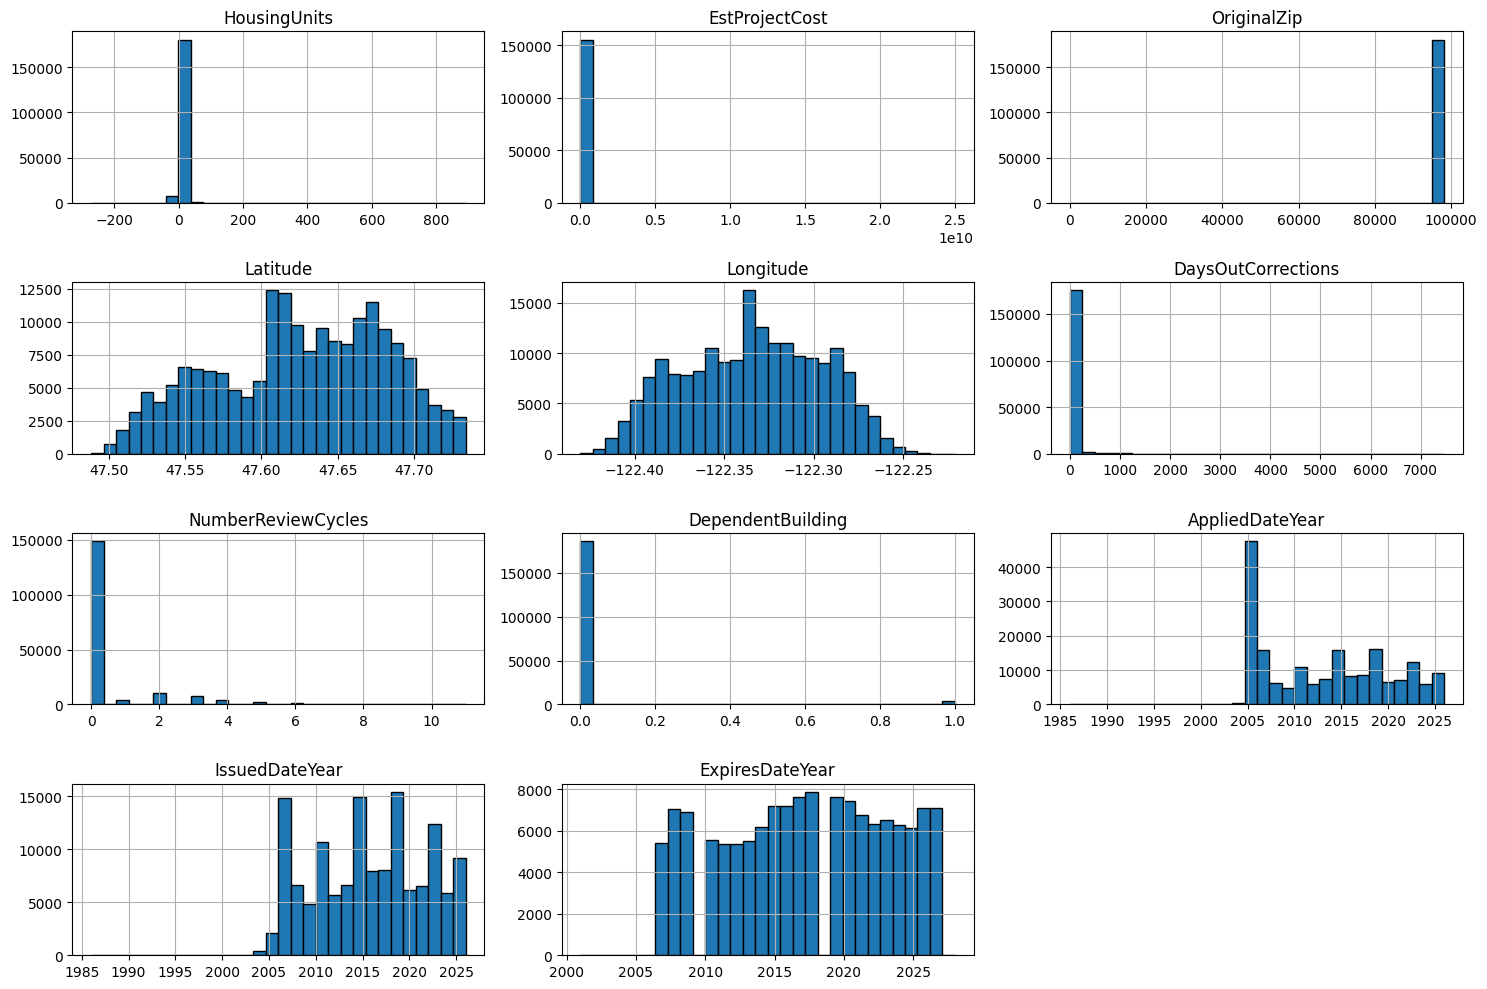

In [18]:
import matplotlib.pyplot as plt
x[num_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.tight_layout()
plt.show()

I've decided to not apply any transformer to the data as there's no real need for it.

# Pipeline & Model

In [19]:
pip install scikit-lego

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.8/227.8 kB 7.0 MB/s eta 0:00:00


In [20]:
pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.3 MB/s eta 0:00:00


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklego.preprocessing import RepeatingBasisFunction
from feature_engine.encoding import CountFrequencyEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer

date_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("encoder",RepeatingBasisFunction())
])
year_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])
num_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy='median')),
    ("scalar",RobustScaler())
])
cat_pipe=Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",CountFrequencyEncoder(encoding_method='frequency'))
])
preprocessor=ColumnTransformer([
    ("date",date_pipe,datetime_col),
    ("cat",cat_pipe,cat_cols),
    ("num",num_pipe,num_cols),
    ("year",year_pipe,year_cols)
])

/usr/local/lib/python3.12/dist-packages/sklego/preprocessing/repeatingbasis.py:81: UserWarning: Please consider using scikit-learn `SplineTransformer` with `extrapolation='periodic'` instead.

Hint: `from sklearn.preprocessing import SplineTransformer`
Docs: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html
  warn(msg, UserWarning)


Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last

dummy score:  0.6975502678022654
classification report                            precision    recall  f1-score   support

                   Active       0.13      1.00      0.23        73
Additional Info Requested       0.49      0.32      0.39      2764
    Application Completed       0.41      0.65      0.50       243
       Approved to Occupy       0.00      0.00      0.00         9
     Awaiting Information       0.31      0.53      0.39       210
                 Canceled       0.80      0.56      0.66      1370
                   Closed       0.74      0.77      0.75      2626
                Completed       0.90      0.92      0.91     39722
     Corrections Required       0.78      0.71      0.74       611
    Corrections Submitted       0.00      0.00      0.00        17
                  Expired       0.54      0.15      0.24      3958
                Initiated       0.03      0.05      0.04        63
    Inspections Completed       0.02      0.25      0.03        44
      

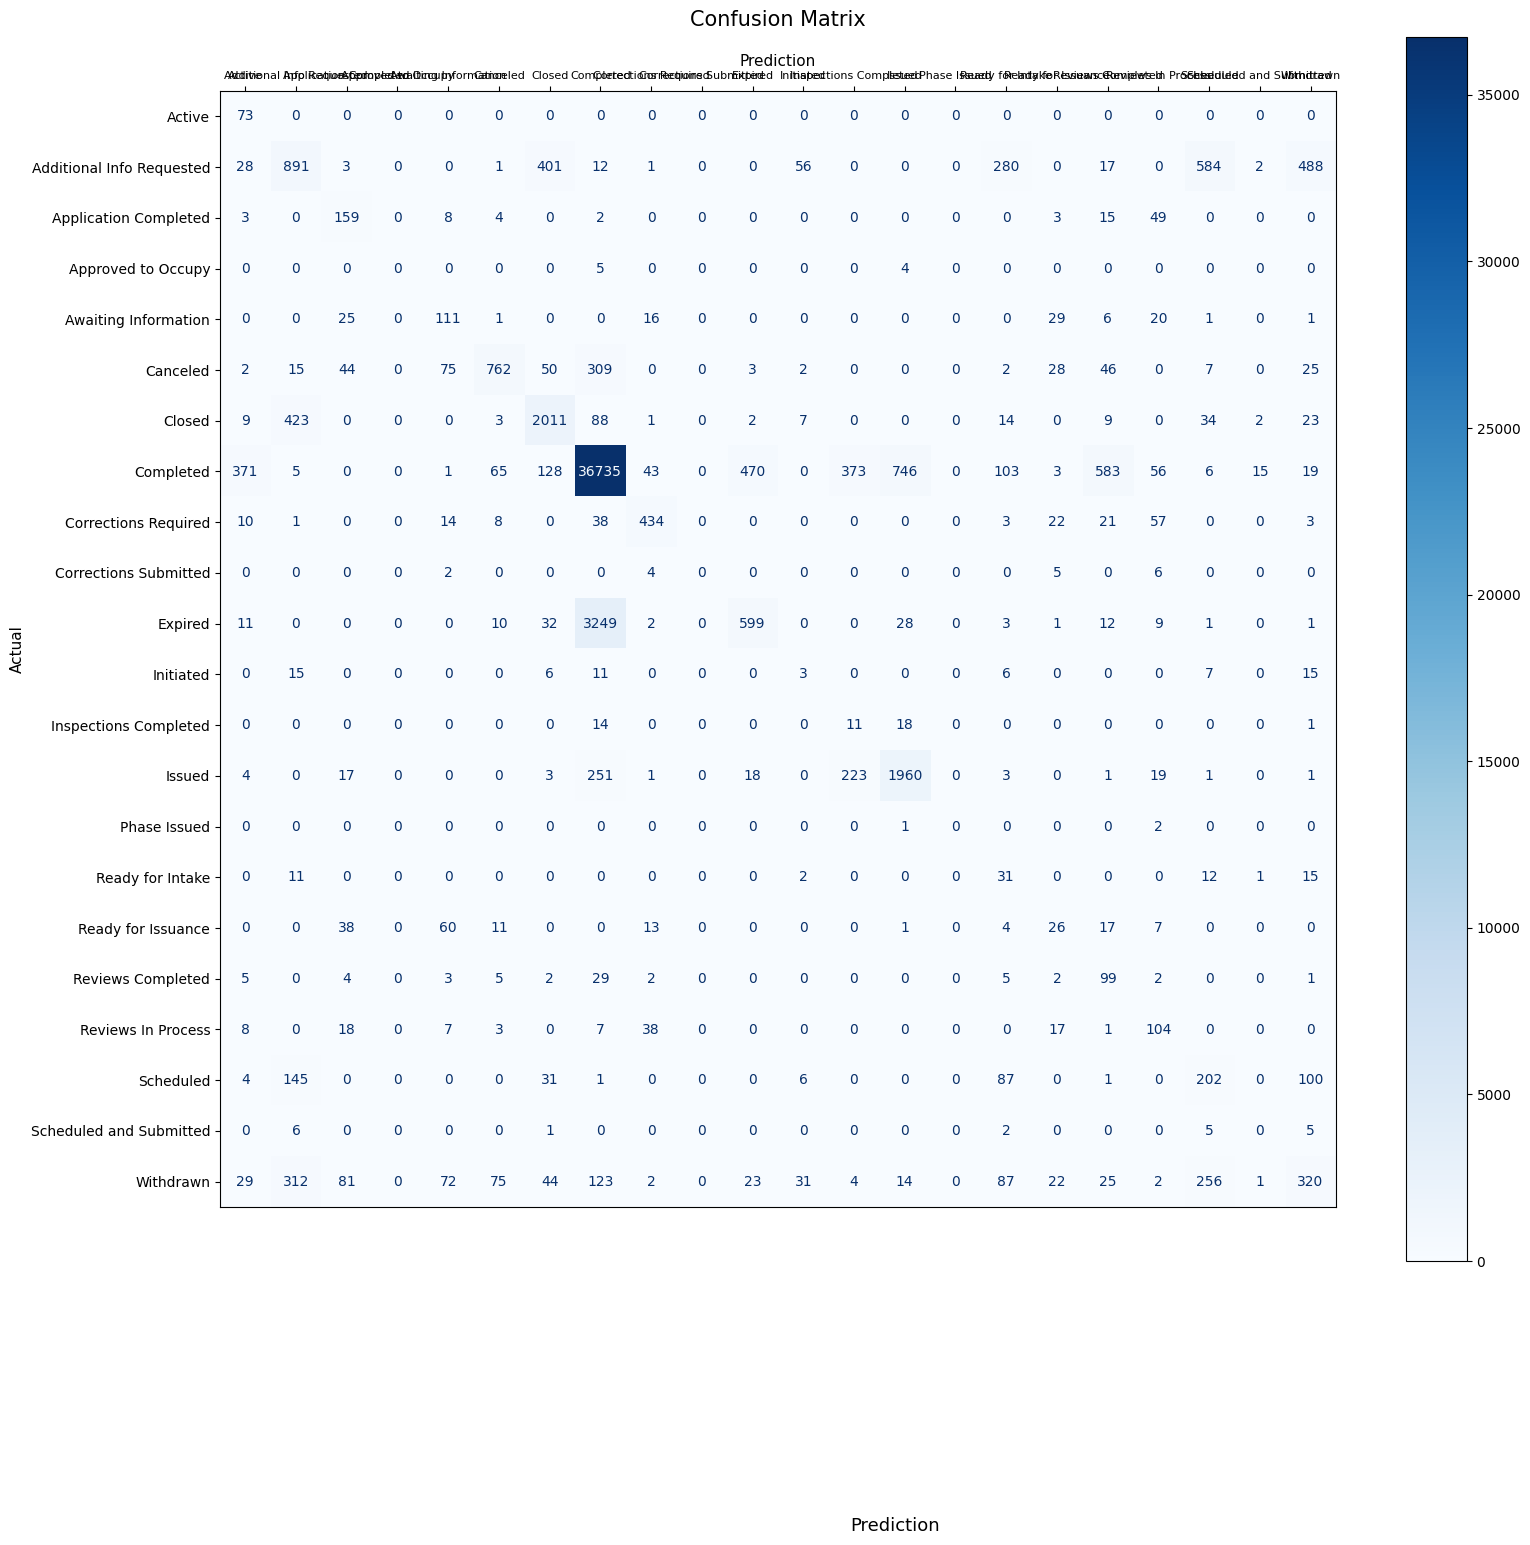

In [22]:
import warnings
# Mute all cosmetic warnings to keep the output clean
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
import tempfile
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRFClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report,accuracy_score

x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3, train_size=0.7,random_state=42,shuffle=True)

#baseline using dummy classifier
dc=DummyClassifier(strategy='most_frequent')
dc.fit(x_train,y_train)
dumscore=dc.score(x_test,y_test)

#The actual model pipeline
model_pipe=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBRFClassifier())
])
#used LabelEncoder to  because the algorithm strictly requires numerical input.
#Specifically, it expects class labels to be integers ranging from 0 to n-1
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

param_distributions={
    'model__learning_rate':[0.01,0.1,1],
    'model__max_depth':[5, 10, 15, 20, 30],
    'model__n_estimators':[50, 100, 150, 200]
}
grid=RandomizedSearchCV(
    estimator=model_pipe,
    param_distributions=param_distributions,
    n_iter=6,
    cv=3,
    n_jobs=-1,
    verbose=2

)
grid.fit(x_train,y_train_encoded)
pred=grid.predict(x_test)
#model_pipe.fit(x_train,y_train)
#pred=model_pipe.predict(x_test)
preds=le.inverse_transform(pred)
cm=confusion_matrix(y_test,preds)

#plotting the confusion matrix
classes=np.unique(y_test)
fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues,ax=ax)
ax.tick_params(axis='x', labelsize=8)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

cr=classification_report(y_test,preds)
print('dummy score: ',dumscore)
print('classification report',cr)

Due to classes with as low as 1 total sample (Pending), standard 3-fold cross-validation strategies will naturally experience fit failures. This occurs because individual data splits are stripped of rare classes entirely, creating a dynamic target schema size that causes algorithms like XGBoost to throw missing sequence value errors during runtime.

               Feature  Permutation Importance
18      IssuedDateYear                0.375757
19     ExpiresDateYear                0.303927
17     AppliedDateYear                0.302451
20    AppliedDateMonth                0.101925
2     PermitTypeMapped                0.085605
3       PermitTypeDesc                0.065593
5       EstProjectCost                0.063916
13  DaysOutCorrections                0.034484
16     HousingCategory                0.024647
4         HousingUnits                0.018542
14  NumberReviewCycles                0.005223
10            Latitude                0.001549
11           Longitude                0.001505
0          PermitClass                0.001305
15   DependentBuilding                0.001210
1    PermitClassMapped                0.000541
9          OriginalZip                0.000516
7         OriginalCity                0.000000
24       IssuedDateDay                0.000000
8        OriginalState                0.000000
22    Expires

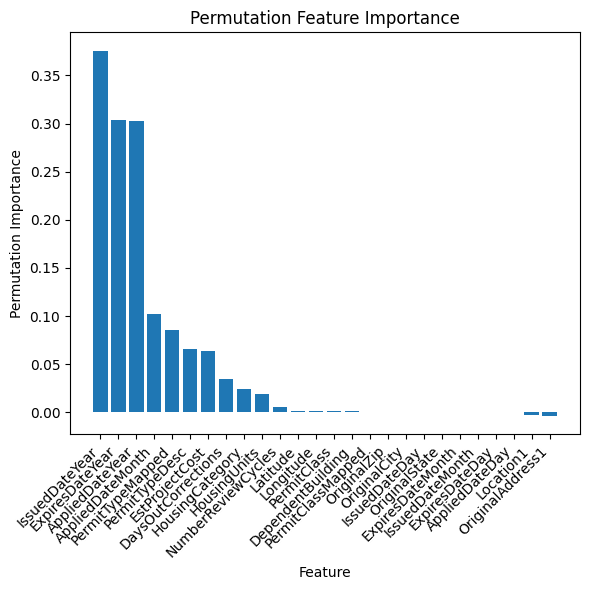

In [23]:
#plotting feature importance using permutation to see which features effect the model the most
#Uses a statistical approach to measure importance by shuffling each feature.
#More robust than Gini importance as it does not depend on model internals.
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

feature_names=x_test.columns
best_model=grid.best_estimator_
result = permutation_importance(best_model,x_test,y_test_encoded, n_repeats=10, random_state=0, n_jobs=-1)
perm_imp_df = pd.DataFrame({'Feature': feature_names, 'Permutation Importance': result.importances_mean}).sort_values(
    'Permutation Importance', ascending=False)
print(perm_imp_df)
plt.figure(figsize=(6, 6))
plt.bar(perm_imp_df['Feature'], perm_imp_df['Permutation Importance'])
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.title('Permutation Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Explanation

#  Post-Mortem Analysis: Why This Model Fails Responsibly

While a final accuracy of 77% looks acceptable on paper, a deeper dive into the metrics reveals that this model is practically useless for real-world deployment. This notebook serves as a case study on how flawed problem formulation, extreme class imbalance, and data leakage create a deceptive illusion of performance.

---

## 1. The Accuracy Trap
* **The Baseline:** A simple `DummyClassifier` that blindly guesses the most frequent class every single time achieves an accuracy of **69.6%**.
* **The Reality:** Our advanced machine learning pipeline only yields a minor improvement (77%). Looking at the **Macro Average F1-Score (0.30)**, we can see that the model completely fails to generalize across the 23 distinct permit statuses. It has essentially memorized the dominant class while guessing wildly on the rest.

---

## 2. Severe Class Imbalance
The target variable, `StatusCurrent`, suffers from extreme class disparity:
* **Completed:** 39,626 samples
* **Approved to Occupy:** 7 samples
* **Pending:** 1 sample

Machine learning algorithms optimize for global accuracy. In this dataset, the mathematical "gravity" of the `Completed` class pulls the decision boundaries entirely toward itself. The model discovers that it is heavily rewarded for predicting the majority class and penalized very little for ignoring rare statuses.

---

## 3. Target Leakage & The Imputation Mask
This project suffers from a conceptual flaw in its goal: trying to predict the current status of a permit using features that are only generated after a status has changed. Specifically, `IssuedDateYear` and `ExpiresDateYear` are clear examples of **Target Leakage**.

However, if these features are "cheating," why didn't the model overfit to 100% accuracy? Two things prevented perfect overfitting:

1. **Imputation Masking:** Permits in early stages like (Active) lack issue or expiration dates. Converting these to datetime created missing values, which were subsequently filled using `SimpleImputer(strategy='median')`. This blended the leaky signals with valid historical data, deeply confusing the model's decision splits.
2. **Feature Subsampling in XGBRFClassifier:** Unlike traditional sequential gradient boosting, the `XGBRFClassifier` utilizes a Random Forest framework. It forces feature subsampling at every node split. Because individual trees were frequently blinded to the leaky date columns, the ensemble was structurally blocked from fully exploiting the data leakage.

---

## Key Takeaway & Future Pivot
This project demonstrates that **no amount of hyperparameter tuning can fix a poorly defined objective.** To transform this into a valuable predictive tool, the problem must be reframed entirely:
1. **Remove Leakage:** Drop all temporal milestones (`IssuedDate`, `ExpiresDate`) and predict outcomes only using data available at the exact second of application.
2. **Consolidate Classes:** Group the 23 granular statuses into 3 macro-categories: `Approved/Completed`, `In-Progress/Delayed`, and `Canceled/Withdrawn`.